--- Starting Lagrangian Relaxation for p-median ---
Iter. |   Lower Bound  |   Upper Bound  |   Gap (%)
-----------------------------------------------------
    1 |         0.0000 |     27215.8408 |   100.000%
   11 |     17677.2684 |     27215.8408 |    35.048%
   21 |     17924.1267 |     27215.8408 |    34.141%
   31 |     18769.0595 |     23228.5850 |    19.198%
   41 |     18831.6462 |     23228.5850 |    18.929%
   51 |     18880.6704 |     23228.5850 |    18.718%
   61 |     19168.7240 |     20369.7287 |     5.896%
   71 |     19211.0118 |     19211.0267 |     0.000%
Convergence achieved: Duality gap is below tolerance.
------------------------------------------------------
Solving exact MIS for comparison...
Final LB: 19211.0118 | Exact: 19211.0267 | Duality Gap: 0.000%


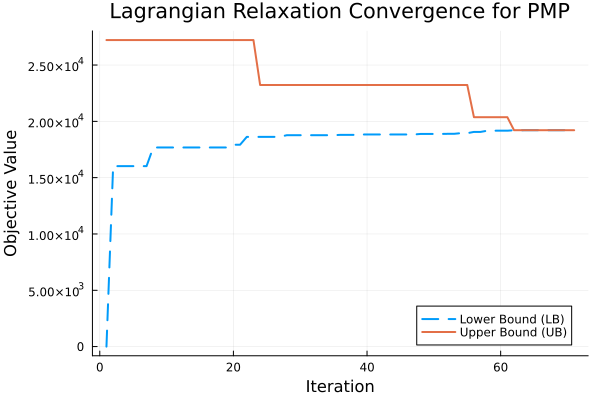

In [8]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: 7.3 - Lagrangian relaxation for p-median
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP            # For mathematical programming
using HiGHS           # HiGHS solver
using CSV             # For reading CSV files
using DataFrames      # For handling DataFrame operations
using Distances       # Distance computations
using LinearAlgebra   # For norm calculations
using Printf          # For formatted output
using Plots           # For plotting

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="Lagrangian Relaxation Convergence for PMP",
        linewidth=2,
        linestyle=[:dash :solid],
        legend=:bottomright)
    display(p)
end

# Function to solve the p-median problem exactly
function solve_pmedian_exact(distance_matrix, p)
    n = size(distance_matrix, 1)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n, 1:n], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(distance_matrix[i,j] * x[i,j] for i in 1:n, j in 1:n))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)  # Each customer assigned to one facility
    # Constraint: Assignment only to open facilities
    @constraint(model, [i=1:n, j=1:n], x[i,j] <= x[j,j])
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in 1:n) == p)
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Main function to solve p-median problem using Lagrangian Relaxation
function solve_pmedian_lagrangian(file_path; p = 3, iterations = 100, gap_tolerance = 0.0001)

    # Load latitude and longitude data
    coordinates = CSV.read(file_path, header=true, DataFrame) |> Matrix{Float64}
    
    # Compute Haversine distance matrix
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)

    # Algorithm Initialization
    n = size(distance_matrix, 1) # Number of clients / facilities
    λ = zeros(n)                 # Lagrange multipliers
    θ = 0.8                      # A factor to update multiplier (Held-Karp)
    LB = -Inf                    # Best lower bound found so far
    UB = Inf                     # Best upper bound found so far
    LB_history = []              # Store lower bound history
    UB_history = []              # Store upper bound history

    # Counter logic for robust convergence
    # Halve θ if UB doesn't improve for 10 iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("--- Starting Lagrangian Relaxation for p-median ---")
    println("Iter. |   Lower Bound  |   Upper Bound  |   Gap (%)")
    println("-----------------------------------------------------")

    for iteration in 1:iterations
        # --- 1. Solve the Lagrangian Subproblem ---

        # 1a. Calculate attractiveness c_j for each facility
        c = [sum(min(0,distance_matrix[i, j] - λ[i]) for i in 1:n) for j in 1:n]

        # 1b. Select the p best facilities (those with the smallest c_j)
        open_facilities_sub = sortperm(c)[1:p]

        # 1c. Calculate the value of the subproblem (v(P_λ))
        # This value is a lower bound on the true optimal solution.
        current_LB = sum(c[open_facilities_sub]) + sum(λ)

        # 1d. Update the Best Lower Bound (LB)
        if current_LB > LB
            LB = current_LB
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Held-Karp Rule: Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                θ *= 0.5
                no_improve_counter = 0
            end
        end
        push!(LB_history, LB)

        # --- 2. Generate a Feasible Solution (Heuristic for Upper Bound) ---

        # 2a. For each customer, assign them to the *closest* open facility
        current_UB = sum([minimum(distance_matrix[i, open_facilities_sub]) for i in 1:n])

        # 2b. Update the best upper bound if this heuristic solution is better
        UB = min(UB, current_UB)
        push!(UB_history, UB)

        # --- 3. Check for termination ---

        # 3a. Calculate duality gap
        gap = (UB - LB) / UB

        # Print iteration results
        if iteration % 10 == 1
            @printf("%5d | %14.4f | %14.4f | %9.3f%%\n", iteration, LB, UB, gap * 100)
        end

        # 3b. Check convergence
        if gap < gap_tolerance
            println("Convergence achieved: Duality gap is below tolerance.")
            break
        end

        # --- 4. Update Multipliers (Subgradient Step) ---

        # 4a. Calculate the subgradient vector g_k
        x_k = zeros(Int, n, n)
        for j in open_facilities_sub
            mask = (distance_matrix[:, j] .- λ) .< 0
            x_k[mask, j] .= 1
        end
        g = ones(n) - sum(x_k, dims=2)[:]

        # 4b. If subgradient is close to zero, we might have an optimal solution
        if norm(g) < 1e-6
            println("Subgradient norm is zero. Stopping.")
            break
        end

        # 4c. Determine the step size α_k (Held-Karp style)
        α = θ * (UB - LB) / (norm(g)^2)

        # 4d. Update the multipliers
        λ .+= α .* g
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_pmedian_exact(distance_matrix, p)
    println("-"^54)
    println("Solving exact MIS for comparison...")
    @printf("Final LB: %.4f | Exact: %.4f | Duality Gap: %.3f%%\n", 
            LB, exact_objective, 100 * abs(exact_objective - LB)/exact_objective)

    # Plot convergence
    plot_convergence(LB_history, UB_history)
end

# Example usage
solve_pmedian_lagrangian("data/sjc_coordinates.csv", p = 3, iterations = 300, gap_tolerance = 1e-6)